In [38]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Split arrays or matrices into random train and test subsets
from sklearn.model_selection import train_test_split

# Encode target labels with value between 0 and n_classes-1, Standardize features by removing the mean and scaling to unit variance.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Logistic Regression (aka logit, MaxEnt) classifier
from sklearn.linear_model import LogisticRegression

# Accuracy classification score, Build a text report showing the main classification metrics, Compute confusion matrix to evaluate the accuracy of a classification
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [15]:
data_path = (
    project_root
    / "data"
    / "processed"
    / "pbmc3k_clustered_annotated.h5ad"
)

adata = sc.read_h5ad(data_path)

print(adata)
print(adata.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 2633 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)
cell_type
CD4 T cells        1175
CD14 Monocytes      639
NK cells            425
B cells             342
Dendritic cells      43
Platelets             9
Name: count, dtype: int64


In [16]:
# use normalized/log-transformed expression from adata.raw
X = adata.raw.X
y = adata.obs["cell_type"].astype(str).to_numpy()

# Convert sparse matrix
if sparse.issparse(x):
    X = X.toarray()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass counts:")
print(adata.obs["cell_type"].value_counts())

X shape: (2633, 13692)
y shape: (2633,)

Class counts:
cell_type
CD4 T cells        1175
CD14 Monocytes      639
NK cells            425
B cells             342
Dendritic cells      43
Platelets             9
Name: count, dtype: int64


In [17]:
hvg_mask  = adata.raw.var_names.isin(
    adata.var_names[adata.var["highly_variable"]]
)

X_hvg = adata.raw.X[:, hvg_mask]

if sparse.issparse(X_hvg):
    X_hvg = X_hvg.toarray()

feature_names = adata.raw.var_names[hvg_mask].to_numpy()

print("X_hvg shape:", X_hvg.shape)
print("Number of features:", len(feature_names))
print("First 10 genes:", feature_names[:10])

X_hvg shape: (2633, 2000)
Number of features: 2000
First 10 genes: ['ISG15' 'TNFRSF4' 'CPSF3L' 'ATAD3C' 'C1orf86' 'RER1' 'TNFRSF25' 'TNFRSF9'
 'CA6' 'CTNNBIP1']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hvg,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class counts:")
print(pd.Series(y_train).value_counts())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts())

Training shape: (2106, 2000)
Test shape: (527, 2000)

Training class counts:
CD4 T cells        940
CD14 Monocytes     511
NK cells           340
B cells            274
Dendritic cells     34
Platelets            7
Name: count, dtype: int64

Test class counts:
CD4 T cells        235
CD14 Monocytes     128
NK cells            85
B cells             68
Dendritic cells      9
Platelets            2
Name: count, dtype: int64


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [21]:
y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy:", accuracy)
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

Test accuracy: 0.9848197343453511

Classification report:
                 precision    recall  f1-score   support

        B cells      0.971     1.000     0.986        68
 CD14 Monocytes      1.000     1.000     1.000       128
    CD4 T cells      0.983     0.983     0.983       235
Dendritic cells      1.000     1.000     1.000         9
       NK cells      0.976     0.953     0.964        85
      Platelets      1.000     1.000     1.000         2

       accuracy                          0.985       527
      macro avg      0.988     0.989     0.989       527
   weighted avg      0.985     0.985     0.985       527



In [22]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=log_reg.classes_
)

print("Classes:")
print(log_reg.classes_)

print("\nConfusion matrix:")
print(cm)

Classes:
['B cells' 'CD14 Monocytes' 'CD4 T cells' 'Dendritic cells' 'NK cells'
 'Platelets']

Confusion matrix:
[[ 68   0   0   0   0   0]
 [  0 128   0   0   0   0]
 [  2   0 231   0   2   0]
 [  0   0   0   9   0   0]
 [  0   0   4   0  81   0]
 [  0   0   0   0   0   2]]


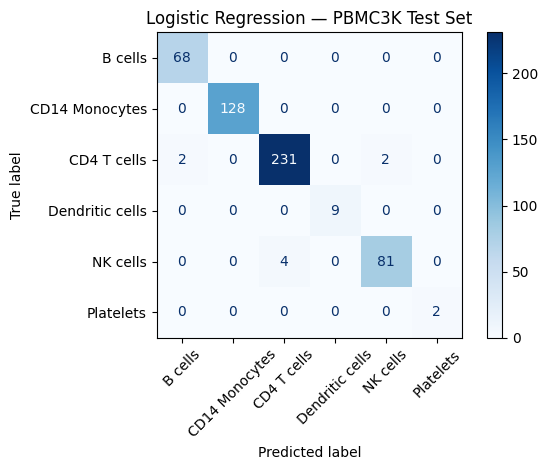

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=log_reg.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Logistic Regression — PBMC3K Test Set")
plt.tight_layout()
plt.show()

In [24]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Cell type mapping:")

for number, cell_type in enumerate(label_encoder.classes_):
    print(f"{number}: {cell_type}")

Cell type mapping:
0: B cells
1: CD14 Monocytes
2: CD4 T cells
3: Dendritic cells
4: NK cells
5: Platelets


In [26]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [27]:
xgb_model.fit(
    X_train,
    y_train_encoded
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [28]:
xgb_pred_encoded = xgb_model.predict(X_test)

xgb_pred = label_encoder.inverse_transform(
    xgb_pred_encoded
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Test Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        digits=3
    )
)

XGBoost Test Accuracy: 0.9791271347248577

Classification Report:
                 precision    recall  f1-score   support

        B cells      0.971     1.000     0.986        68
 CD14 Monocytes      0.992     1.000     0.996       128
    CD4 T cells      0.983     0.979     0.981       235
Dendritic cells      1.000     0.889     0.941         9
       NK cells      0.953     0.953     0.953        85
      Platelets      1.000     0.500     0.667         2

       accuracy                          0.979       527
      macro avg      0.983     0.887     0.921       527
   weighted avg      0.979     0.979     0.979       527



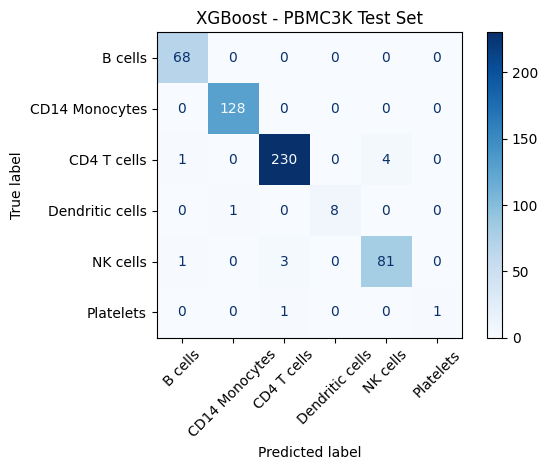

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("XGBoost - PBMC3K Test Set")
plt.tight_layout()
plt.show()

In [31]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        0.9848197343453511,
        0.9791271347248577
    ],
    "Macro F1": [
        0.989,
        0.921
    ],
    "Weighted F1": [
        0.985,
        0.979
    ]
})

model_results

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.984820,0.989,0.985
1,XGBoost,0.979127,0.921,0.979


In [33]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [34]:
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Test Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

Random Forest Test Accuracy: 0.9753320683111955

Classification Report:
                 precision    recall  f1-score   support

        B cells      0.971     1.000     0.986        68
 CD14 Monocytes      0.977     1.000     0.988       128
    CD4 T cells      0.983     0.974     0.979       235
Dendritic cells      1.000     0.667     0.800         9
       NK cells      0.953     0.965     0.959        85
      Platelets      1.000     0.500     0.667         2

       accuracy                          0.975       527
      macro avg      0.981     0.851     0.896       527
   weighted avg      0.976     0.975     0.975       527



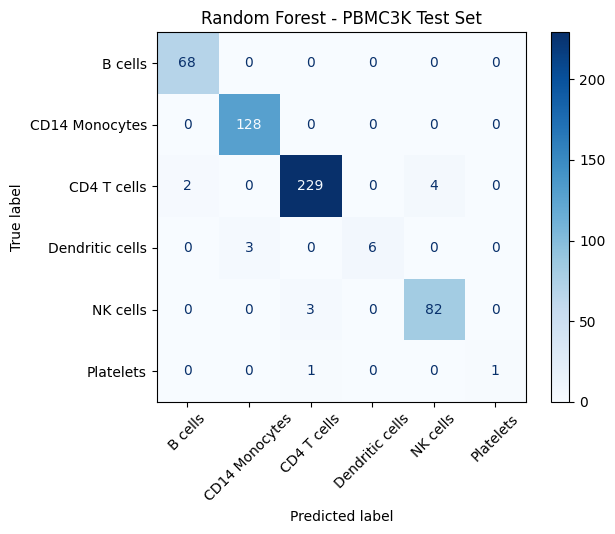

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    labels=rf_model.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Random Forest - PBMC3K Test Set")
plt.tight_layout
plt.show()

In [37]:
from sklearn.metrics import f1_score

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
})

model_results.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.984820,0.988795,0.984779
1,XGBoost,0.979127,0.920535,0.978768
2,Random Forest,0.975332,0.896381,0.974505


In [ ]:
log_reg_pipeline = PipeLine([
    ("scaler", StandardScaler()),
    ("classifier", 